In [4]:
# Importar librerias
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [5]:
conn = sqlite3.connect('industria_Neuquen.db')
query =  "SELECT * FROM sensores"
df = pd.read_sql_query(query, conn)
conn.close()
print("----Data Frame creado----")

----Data Frame creado----


In [6]:
df.head()

,ID_Registro,Codigo_Producto,Categoria,Temp_Ambiente_C,Temp_Proceso_C,Velocidad_RPM,Torque,Desgaste_Herramienta_min,Falla_Detectada
0,1,M14860,M,24.95,35.45,1551,42.8,0,0
1,2,L47181,L,25.05,35.55,1408,46.3,3,0
2,3,L47182,L,24.95,35.35,1498,49.4,5,0
3,4,L47183,L,25.05,35.45,1433,39.5,7,0
4,5,L47184,L,25.05,35.55,1408,40.0,9,0


In [7]:
df['Diferencia_Temp'] = df['Temp_Proceso_C'] - df['Temp_Ambiente_C']


In [8]:
df.head()

,ID_Registro,Codigo_Producto,Categoria,Temp_Ambiente_C,Temp_Proceso_C,Velocidad_RPM,Torque,Desgaste_Herramienta_min,Falla_Detectada,Diferencia_Temp
0,1,M14860,M,24.95,35.45,1551,42.8,0,0,10.5
1,2,L47181,L,25.05,35.55,1408,46.3,3,0,10.5
2,3,L47182,L,24.95,35.35,1498,49.4,5,0,10.4
3,4,L47183,L,25.05,35.45,1433,39.5,7,0,10.4
4,5,L47184,L,25.05,35.55,1408,40.0,9,0,10.5


In [9]:
feacture = df.drop(['ID_Registro', 'Falla_Detectada','Codigo_Producto','Categoria'],axis=1)
target = df['Falla_Detectada']

In [10]:
x = feacture
y = target

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
Model_1 = RandomForestClassifier(n_estimators=100 ,random_state=42)
Model_1.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

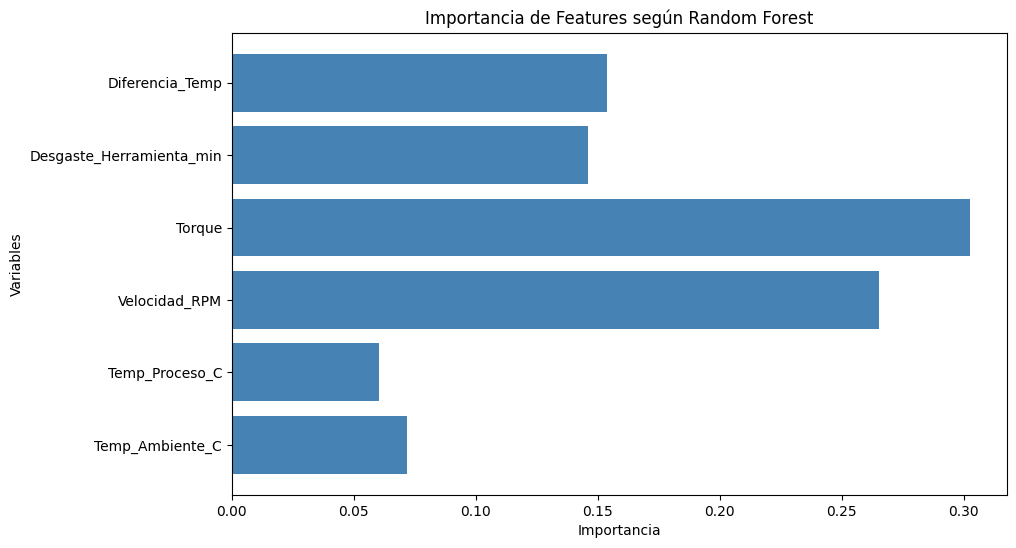

In [13]:
# Importancia de variables
importancias = Model_1.feature_importances_

# Crear gráfico
plt.figure(figsize=(10,6))
plt.barh(x.columns, importancias, color="steelblue")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.title("Importancia de Features según Random Forest")
plt.show()

In [14]:
y_pred = Model_1.predict(x_test)

In [15]:
presicion = classification_report(y_test, y_pred)
print(presicion)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.87      0.64      0.74        61

    accuracy                           0.99      2000
   macro avg       0.93      0.82      0.86      2000
weighted avg       0.99      0.99      0.98      2000



<Figure size 600x600 with 0 Axes>

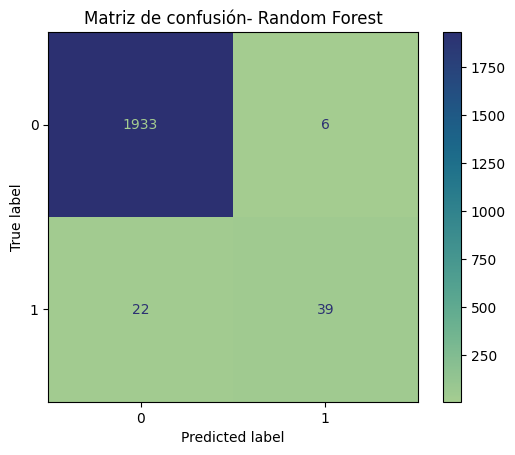

In [16]:
matriz= confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=Model_1.classes_)
plt.figure(figsize=(6,6))
disp.plot(cmap="crest", values_format="d")
plt.title("Matriz de confusión- Random Forest")
plt.show()


/tmp/ipykernel_2152/3015129045.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values, palette="crest")


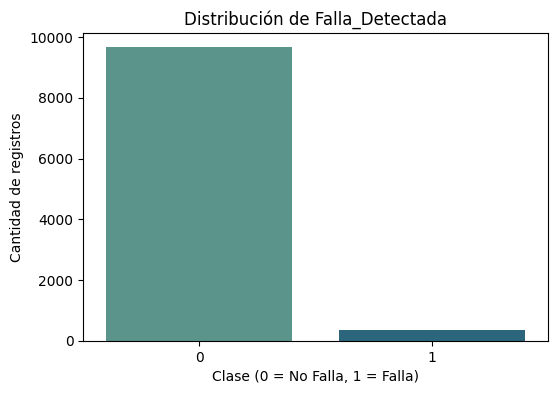

In [17]:
conteo = y.value_counts()

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.barplot(x=conteo.index, y=conteo.values, palette="crest")
plt.title("Distribución de Falla_Detectada")
plt.xlabel("Clase (0 = No Falla, 1 = Falla)")
plt.ylabel("Cantidad de registros")
plt.show()





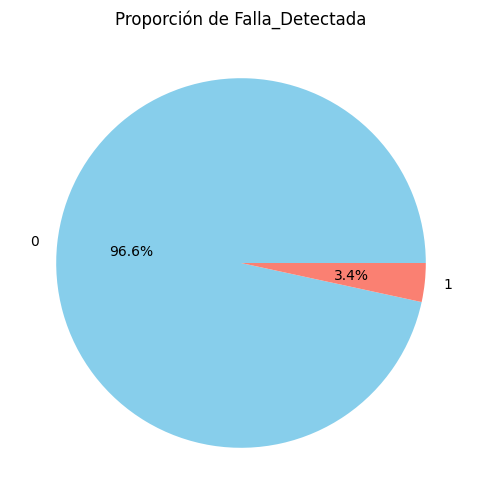

In [18]:
plt.figure(figsize=(6,6))
plt.pie(conteo.values, labels=conteo.index, autopct='%1.1f%%', colors=["skyblue","salmon"])
plt.title("Proporción de Falla_Detectada")
plt.show()

In [19]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [20]:
smoted = SMOTE(random_state=42)
x_train_smoted, y_train_smoted = smoted.fit_resample(x_train_scaled, y_train)


/tmp/ipykernel_2152/2626716156.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo2.index, y=conteo2.values, palette="crest")


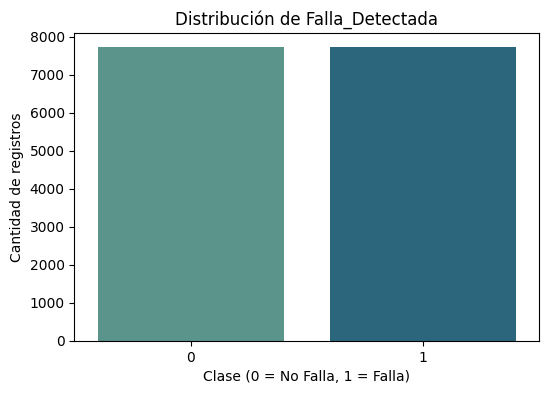

In [21]:
conteo2 = y_train_smoted.value_counts()

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.barplot(x=conteo2.index, y=conteo2.values, palette="crest")
plt.title("Distribución de Falla_Detectada")
plt.xlabel("Clase (0 = No Falla, 1 = Falla)")
plt.ylabel("Cantidad de registros")
plt.show()

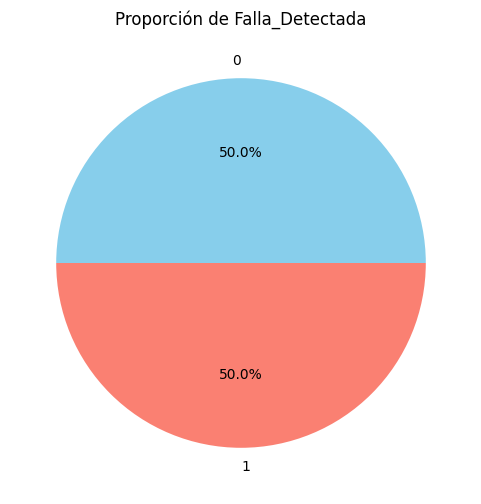

In [22]:
plt.figure(figsize=(6,6))
plt.pie(conteo2.values, labels=conteo2.index, autopct='%1.1f%%', colors=["skyblue","salmon"])
plt.title("Proporción de Falla_Detectada")
plt.show()

In [23]:
Model_2 = RandomForestClassifier(n_estimators=100, random_state=42)
Model_2.fit(x_train_smoted, y_train_smoted)

RandomForestClassifier(random_state=42)

In [24]:
y_pred_2= Model_2.predict(x_test_scaled)

In [25]:
result = classification_report(y_test, y_pred_2)
print(result)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1939
           1       0.53      0.79      0.63        61

    accuracy                           0.97      2000
   macro avg       0.76      0.88      0.81      2000
weighted avg       0.98      0.97      0.97      2000



<Figure size 600x600 with 0 Axes>

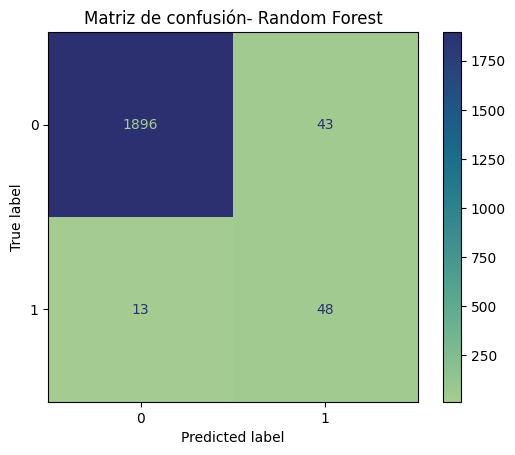

In [26]:
matriz2= confusion_matrix(y_test, y_pred_2)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz2, display_labels=Model_2.classes_)
plt.figure(figsize=(6,6))
disp.plot(cmap="crest", values_format="d")
plt.title("Matriz de confusión- Random Forest")
plt.show()


In [27]:
#### MODELO DEFINITIVO

In [28]:
pipeline_xgb = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

In [29]:
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5, 7],         # Árboles más profundos o más cortos
    'xgb__learning_rate': [0.01, 0.1]    # Velocidad de aprendizaje del algoritmo
}
grid_search = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    cv=5,                 # 5 pliegues de validación cruzada
    scoring='f1',         # Optimizamos para equilibrar Precision y Recall en la falla
    n_jobs=-1             # Usa todos los núcleos disponibles para ir más rápido
)

In [30]:
grid_search.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:18:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_types=None,
                                                      feature_...
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': [0.01, 0.1],
                         'xgb__max_depth': [3, 5, 7],
                         'xgb__n_estimators': [100, 200]},
             scoring='f1')

In [31]:
print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 200}


In [32]:
# 5. Evaluar el mejor modelo en el set de testeo
mejores_predicciones = grid_search.predict(x_test)
print(classification_report(y_test, mejores_predicciones))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1939
           1       0.57      0.85      0.68        61

    accuracy                           0.98      2000
   macro avg       0.78      0.92      0.83      2000
weighted avg       0.98      0.98      0.98      2000



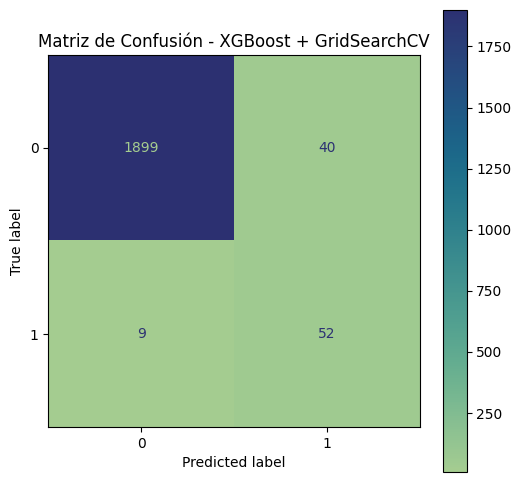

In [33]:
# 1. Calcular la matriz con las predicciones del mejor modelo (XGBoost)
matriz_xgb = confusion_matrix(y_test, mejores_predicciones)

# 2. Configurar la visualización
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_xgb,
    display_labels=grid_search.best_estimator_.classes_
)

# 3. Graficar
disp.plot(cmap="crest", values_format="d", ax=ax)
plt.title("Matriz de Confusión - XGBoost + GridSearchCV")
plt.show()